In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Target variable distribution
print("\nOutcome Distribution:")
print(df["Outcome"].value_counts())

Dataset Shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
Pregnancies  

In [4]:
# Separate features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (768, 8)
Target Shape: (768,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (614, 8)
Testing Data Shape: (154, 8)


In [6]:
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (614, 8)
Scaled Testing Shape: (154, 8)


In [7]:
svm_model = SVC(kernel='rbf')

# Train the model
svm_model.fit(X_train_scaled, y_train)

print("SVM model training completed")

SVM model training completed


In [8]:
# Predict on test data
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

Model Accuracy: 0.7337662337662337

Confusion Matrix:
 [[82 17]
 [24 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



In [9]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Grid Search
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)

# Train using grid search
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Model:", grid.best_estimator_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.

In [10]:
# Use the best model found by GridSearch
best_svm = grid.best_estimator_

# Predict using the tuned model
y_pred_best = best_svm.predict(X_test_scaled)

# Accuracy
best_accuracy = accuracy_score(y_test, y_pred_best)
print("Tuned SVM Accuracy:", best_accuracy)

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:\n", cm_best)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Tuned SVM Accuracy: 0.7727272727272727

Confusion Matrix:
 [[82 17]
 [18 37]]

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.83      0.82        99
           1       0.69      0.67      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



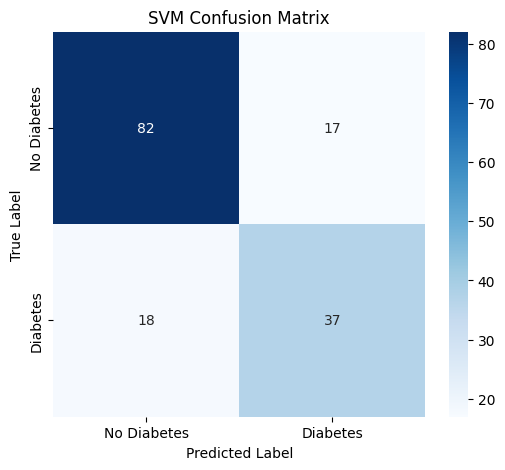

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, cmap="Blues", fmt="d",
            xticklabels=["No Diabetes","Diabetes"],
            yticklabels=["No Diabetes","Diabetes"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.show()